In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration')
os.getcwd()

'/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration'

In [4]:
embryomodel = ad.read_h5ad("embryo_model_integration_scPoli.h5ad")

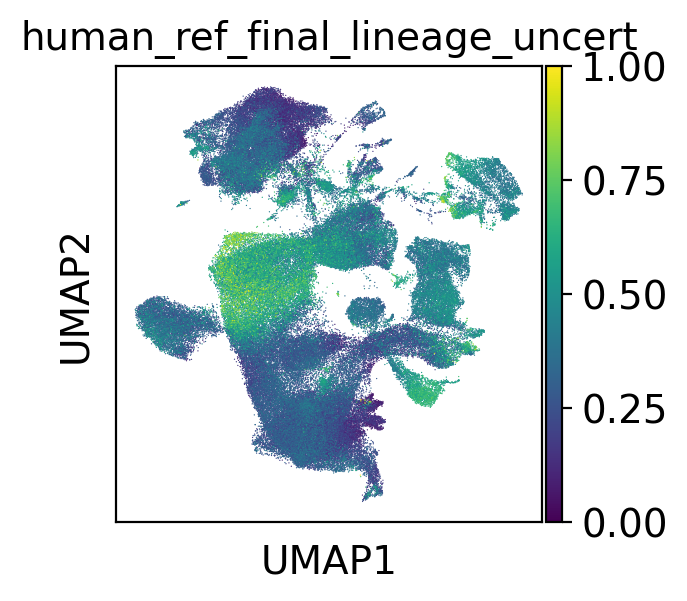

In [5]:
sc.pl.umap(embryomodel, color=['human_ref_final_lineage_uncert'])

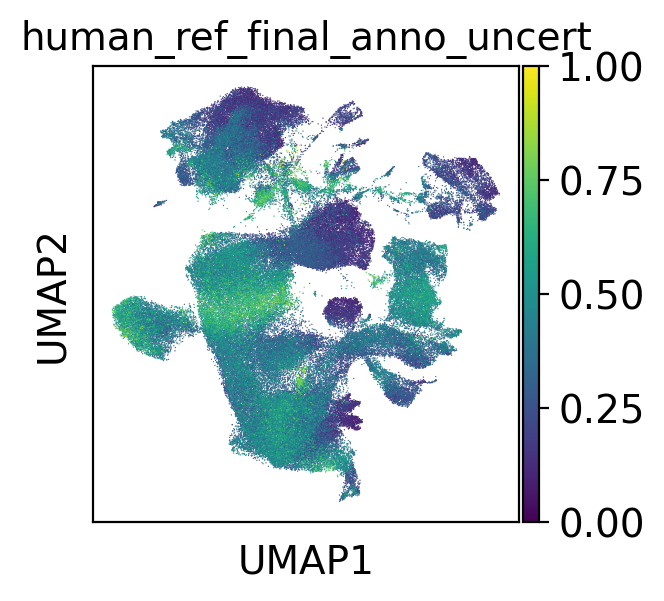

In [6]:
sc.pl.umap(embryomodel, color=['human_ref_final_anno_uncert'])

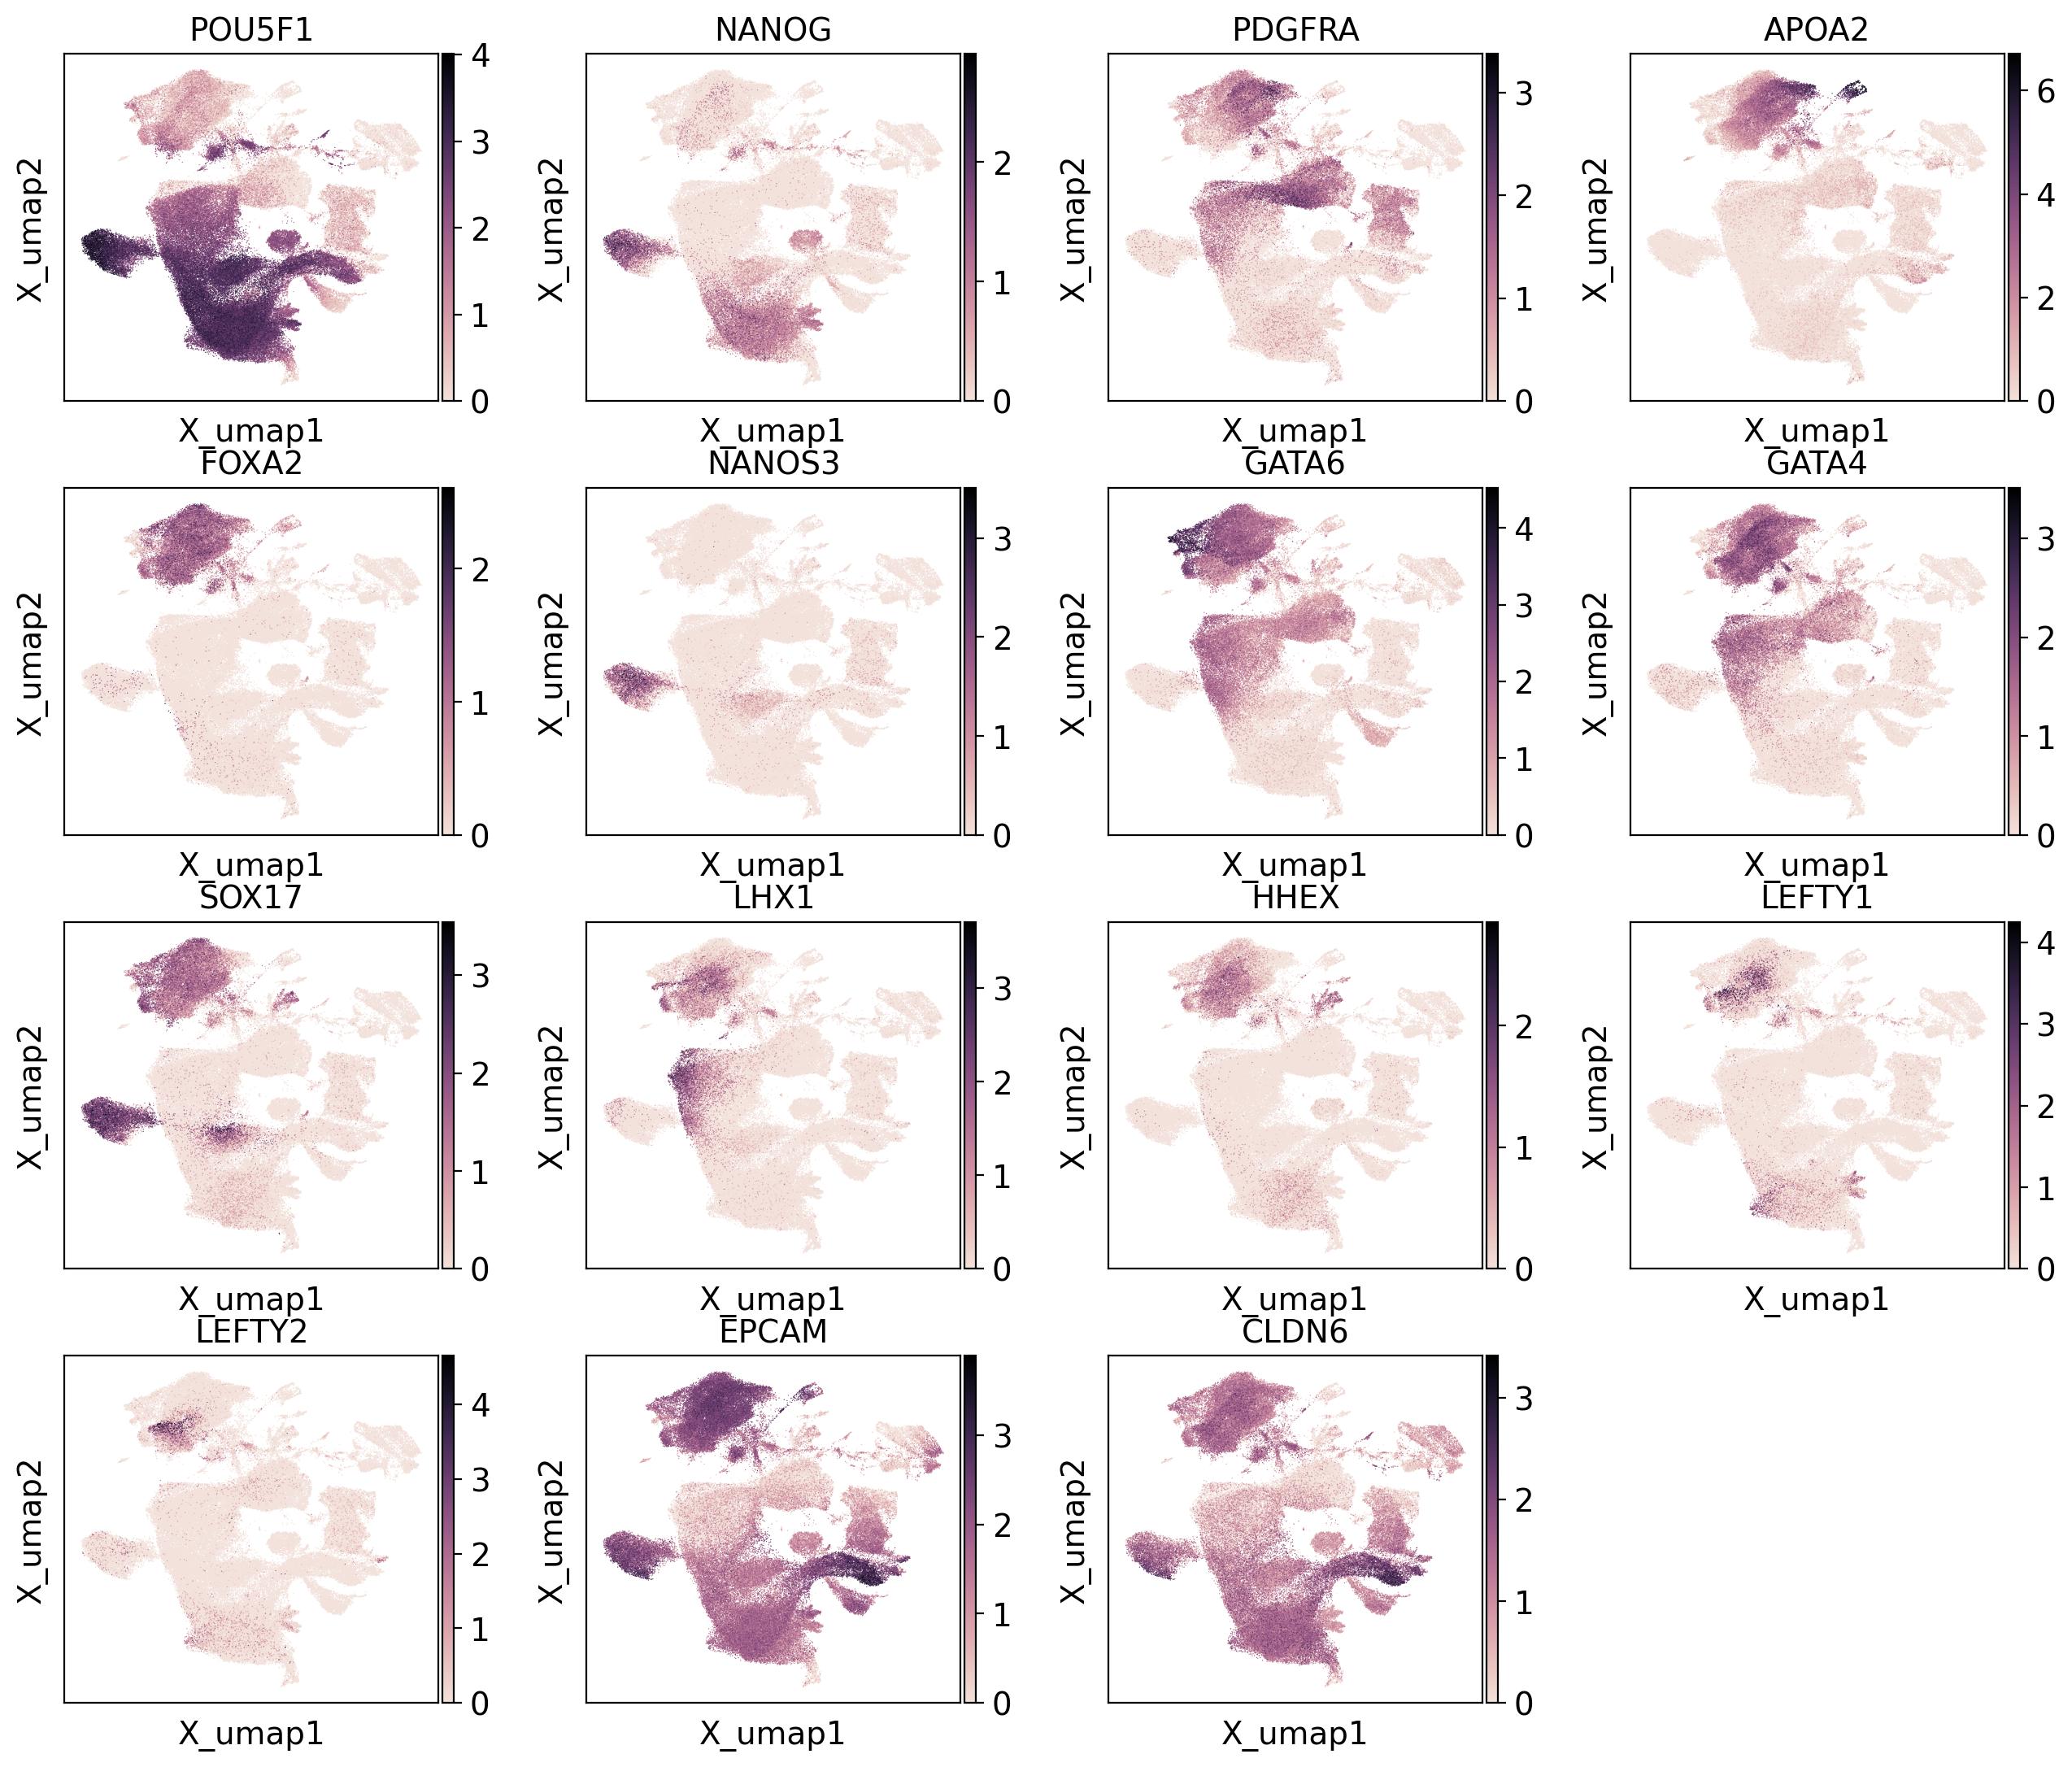

In [7]:
# Define the list of genes you want to plot
genes_to_plot = ["POU5F1","NANOG",#epiblast
                # "SOX2", "TTYH1", #Neural_ectoderm
                # "GATA3","TFAP2A",
                # "TBXT",  "CDX1",
                 "PDGFRA","APOA2","FOXA2","NANOS3",
               # "PECAM1","HBZ","PTPRC",
                #"GABRP","HEY1","COL6A1","COL6A2",
                "GATA6", "GATA4", "SOX17", "LHX1", "HHEX","LEFTY1", "LEFTY2", "EPCAM", "CLDN6"]  # Replace "GENE2" and "GENE3" with the actual gene names

# Plot the UMAP embedding for the specified genes
sc.pl.embedding(
    embryomodel,
    basis='X_umap',
    color=genes_to_plot,
    use_raw=False,
    cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True)
)

In [7]:
embryomodel

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_final_anno_pred_colors', 'human_ref_final_lineage_pred_colors', 'hvg', 'leiden', 'leiden_res_0.80_colors', 'leiden_res_1.00_colors', 'leiden_res_1.50_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'scANVI_res_0.5_colors', 'stage_colors', 'umap'
    obsm: 'Unintegrated', 'X_

In [8]:
# Step 1: Identify indices of high-confidence cells
high_confidence_indices = np.where(
    (embryomodel.obs["human_ref_final_lineage_uncert"] < 0.1) | 
    (embryomodel.obs["human_ref_final_anno_pred"] =="PGC")
)[0]
# Step 2: Extract high-confidence cells
high_confidence_cells = embryomodel[high_confidence_indices]

# Step 3: Extract high-confidence labels (cell type annotations)
high_confidence_labels = embryomodel.obs["human_ref_final_lineage_pred"].iloc[high_confidence_indices]


In [9]:
print(high_confidence_cells.X)

  (0, 11375)	0.9811418604730859
  (0, 24981)	4.35291985215031
  (0, 24987)	2.2340387736852048
  (0, 24985)	3.7922256863362382
  (0, 24984)	3.4868400088045557
  (0, 24980)	4.529503554366199
  (0, 24976)	4.6156156913756385
  (0, 24977)	0.9811418604730859
  (0, 24979)	4.836778063731319
  (0, 24978)	4.564843108162622
  (0, 24983)	2.2340387736852048
  (0, 24982)	2.962304984516597
  (0, 33698)	0.9811418604730859
  (0, 21303)	0.9811418604730859
  (0, 29198)	3.899089974951192
  (0, 25253)	0.9811418604730859
  (0, 13343)	1.4667218025624078
  (0, 14635)	0.9811418604730859
  (0, 33766)	0.9811418604730859
  (0, 19733)	1.4667218025624078
  (0, 8352)	1.4667218025624078
  (0, 28722)	0.9811418604730859
  (0, 29391)	0.9811418604730859
  (0, 24757)	0.9811418604730859
  (0, 28587)	1.7921762574639888
  :	:
  (7290, 20952)	0.9944685674433726
  (7290, 15402)	0.9944685674433726
  (7290, 17281)	2.338731893742921
  (7290, 28813)	1.9403957880196152
  (7290, 26724)	1.2683356585275651
  (7290, 14243)	0.6160737161

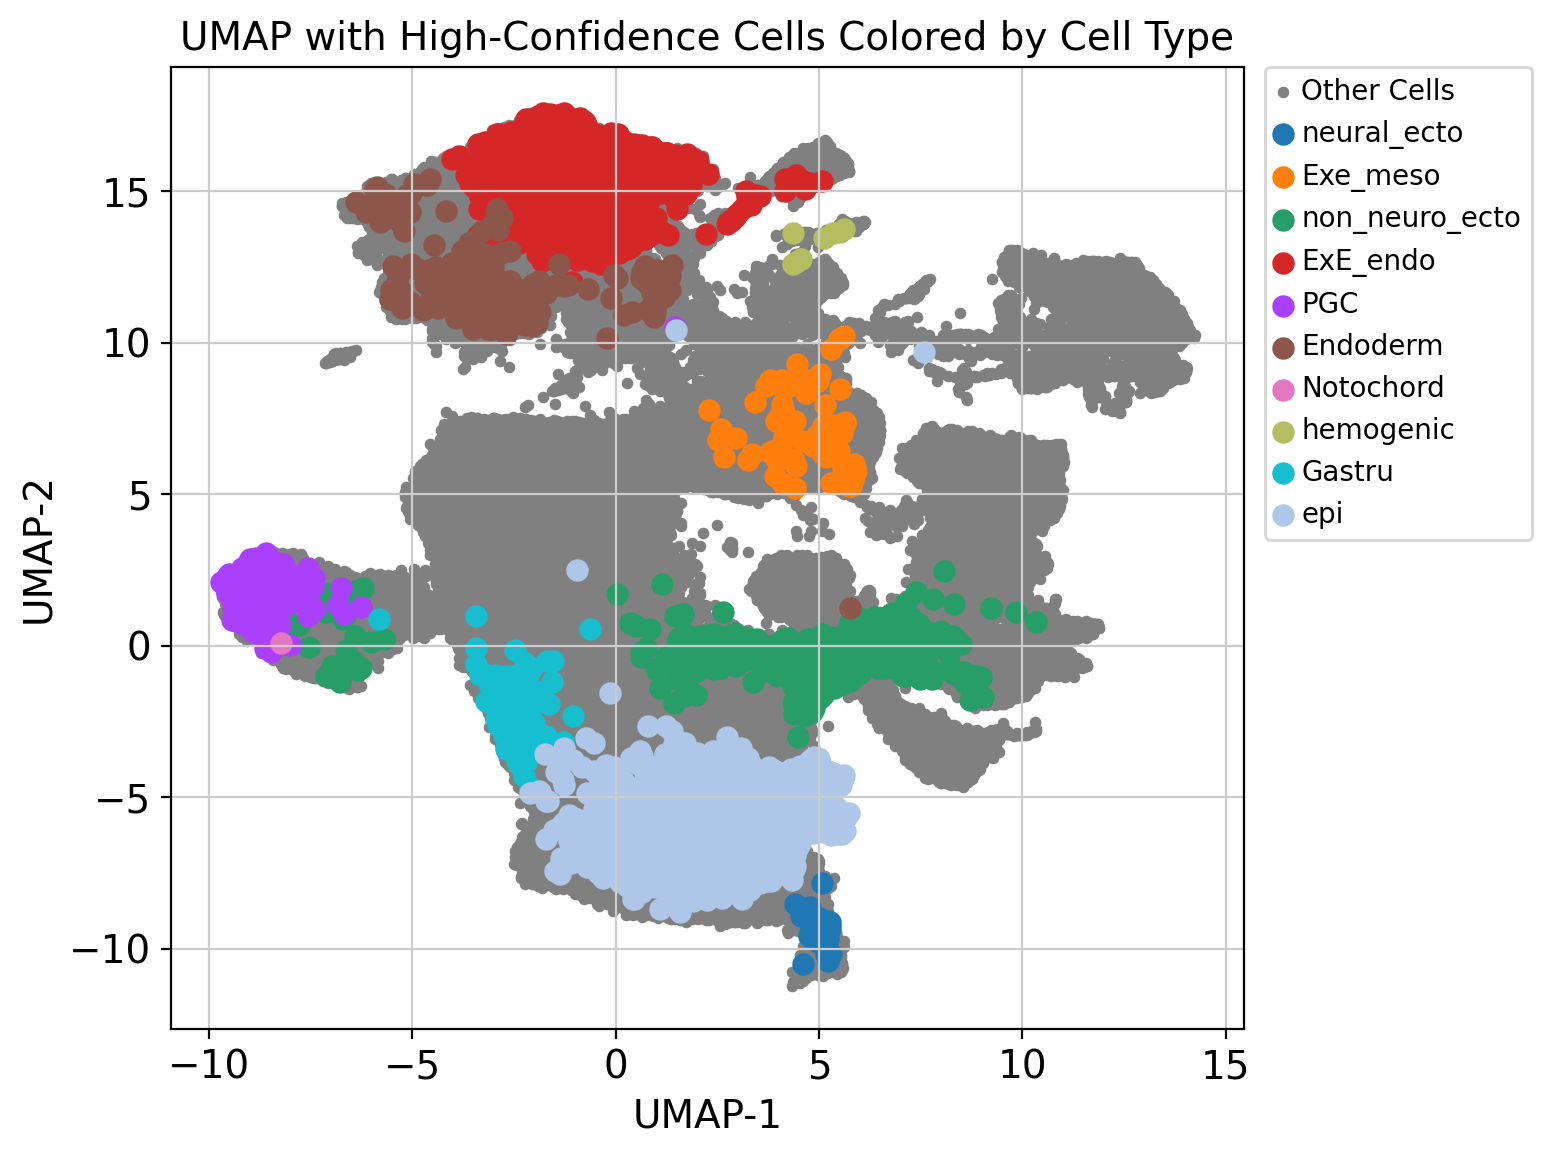

In [10]:
# Ensure UMAP coordinates exist
if "X_umap" not in embryomodel.obsm:
    raise ValueError("UMAP coordinates (embryomodel.obsm['X_umap']) are missing. Please compute UMAP first.")

# Extract UMAP coordinates for all cells
umap_coords = embryomodel.obsm["X_umap"]

# Create a mask for high-confidence cells
is_high_confidence = np.zeros(embryomodel.shape[0], dtype=bool)  # Initialize mask
is_high_confidence[high_confidence_indices] = True         # Mark high-confidence cells

# Plot all cells in grey
plt.figure(figsize=(8, 6))
# Plot all cells in grey
plt.scatter(
    umap_coords[~is_high_confidence, 0],
    umap_coords[~is_high_confidence, 1],
    c="grey",
    s=10,
    label="Other Cells"
)

# Overlay high-confidence cells colored by cell type
for label in set(high_confidence_labels):
    label_indices = high_confidence_indices[high_confidence_labels == label]
    plt.scatter(
        umap_coords[label_indices, 0],
        umap_coords[label_indices, 1],
        label=label,
        s=50
    )

# Add legend and finalize plot
plt.title("UMAP with High-Confidence Cells Colored by Cell Type")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Move legend outside the frame
plt.legend(
    loc="upper left",                     # Position relative to the plot
    bbox_to_anchor=(1.02, 1),             # Offset to place legend outside
    borderaxespad=0,                      # Padding between legend and axes
    fontsize=10                           # Optional: Adjust font size
)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

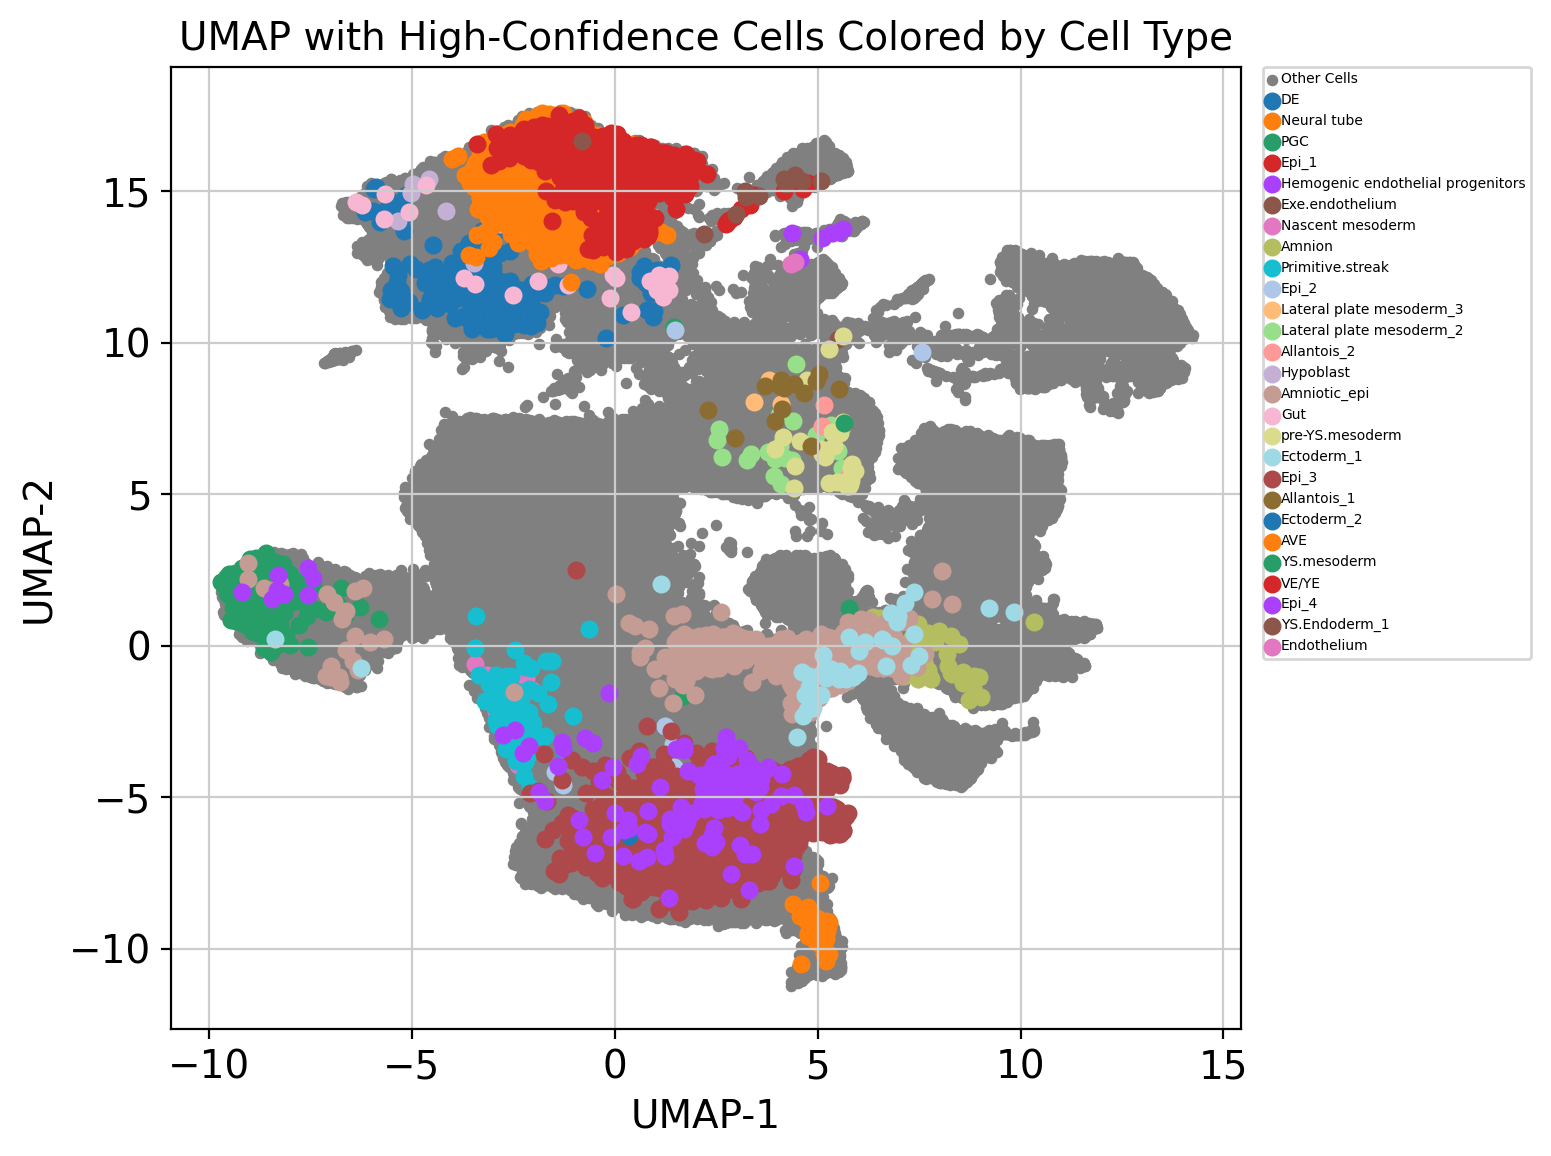

In [11]:
# Step 3: Extract high-confidence labels (cell type annotations)
high_confidence_labels = embryomodel.obs["human_ref_final_anno_pred"][high_confidence_indices]

# Ensure UMAP coordinates exist
if "X_umap" not in embryomodel.obsm:
    raise ValueError("UMAP coordinates (embryomodel.obsm['X_umap']) are missing. Please compute UMAP first.")

# Extract UMAP coordinates for all cells
umap_coords = embryomodel.obsm["X_umap"]

# Create a mask for high-confidence cells
is_high_confidence = np.zeros(embryomodel.shape[0], dtype=bool)  # Initialize mask
is_high_confidence[high_confidence_indices] = True         # Mark high-confidence cells

# Plot all cells in grey
plt.figure(figsize=(8, 6))
# Plot all cells in grey
plt.scatter(
    umap_coords[~is_high_confidence, 0],
    umap_coords[~is_high_confidence, 1],
    c="grey",
    s=10,
    label="Other Cells"
)

# Overlay high-confidence cells colored by cell type
for label in set(high_confidence_labels):
    label_indices = high_confidence_indices[high_confidence_labels == label]
    plt.scatter(
        umap_coords[label_indices, 0],
        umap_coords[label_indices, 1],
        label=label,
        s=30
    )

# Add legend and finalize plot
plt.title("UMAP with High-Confidence Cells Colored by Cell Type")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Move legend outside the frame
plt.legend(
    loc="upper left",                     # Position relative to the plot
    bbox_to_anchor=(1.02, 1),             # Offset to place legend outside
    borderaxespad=0,                      # Padding between legend and axes
    fontsize=5                           # Optional: Adjust font size
)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

In [12]:
from scarches.models.scpoli import scPoli
from scarches.dataset.trvae.data_handling import remove_sparsity

#load reference data
# Load dataset
adata = sc.read('/storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/human_reanno_20250108.h5ad')
adata

# Reorganize adata with highly variable genes (HVGs)
adata_hvg = adata[:, adata.var.highly_variable].copy()

print("Original obs:", adata_hvg.obs.columns)
print("Original var:", adata_hvg.var.columns)
print("Original uns:", adata_hvg.uns.keys())
print("Original obsm:", adata_hvg.obsm.keys())
print("Original varm:", adata_hvg.varm.keys())
print("Original layers:", adata_hvg.layers.keys())

obs_to_keep = ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'ann_level_2', 'ann_level_3', 'ann_level_1', 'final_anno', 'final_lineage']
obs_columns_to_remove = [col for col in adata_hvg.obs.columns if col not in obs_to_keep]
adata_hvg.obs.drop(columns=obs_columns_to_remove, inplace=True)

features_to_keep = ['features']
var_columns_to_remove = [col for col in adata_hvg.var.columns if col not in features_to_keep]
adata_hvg.var.drop(columns=var_columns_to_remove, inplace=True)

adata_hvg.uns = {}
adata_hvg.obsm = {}
adata_hvg.varm = {}

layers_to_keep = ['counts']
layers_keys_to_remove = [key for key in adata_hvg.layers.keys() if key not in layers_to_keep]
for key in layers_keys_to_remove:
    del adata_hvg.layers[key]

print("Modified obs:", adata_hvg.obs.columns)
print("Modified var:", adata_hvg.var.columns)
print("Modified uns:", adata_hvg.uns.keys())
print("Modified obsm:", adata_hvg.obsm.keys())
print("Modified varm:", adata_hvg.varm.keys())
print("Modified layers:", adata_hvg.layers.keys())

counts_matrix = adata_hvg.layers["counts"].toarray()
adata = sc.AnnData(
    X=counts_matrix,
    obs=adata_hvg.obs.copy(),
    var=adata_hvg.var.copy(),
    uns=adata_hvg.uns.copy(),
    obsm=adata_hvg.obsm.copy(),
    varm=adata_hvg.varm.copy(),
    layers={'counts': counts_matrix}
)

adata = remove_sparsity(adata)

# Use adata as the reference
source_adata = adata.copy()


Original obs: Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage',
       'percent.mt', 'species', 'embryo', 'platform', 'ann_level_2',
       'ann_level_3', 'ann_level_1', 'doublet', 'doublet_score',
       'Unintegrated_res_0.5', 'Scanorama_res_0.5', 'LIGER_res_0.5',
       'Harmony_res_0.5', 'scVI_res_0.5', 'scANVI_res_0.5', 'CCA_res_0.5',
       'FastMNN_res_0.5', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4',
       'reanno', 'lineage', 'unicorns', 'combined_annotation', 'final_anno',
       'final_lineage'],
      dtype='object')
Original var: Index(['features', 'n_cells', 'highly_variable', 'means', 'dispersions',
       'dispersions_norm', 'highly_variable_nbatches',
       'highly_variable_intersection'],
      dtype='object')
Original uns: dict_keys(['CCA_res_0.5_colors', 'FastMNN_res_0.5_colors', 'Harmony_res_0.5_colors', 'LIGER_res_0.5_colors', 'Scanorama_res_0.5_colors', 'Unintegrated_res_0.5_colors', 'anno_colors', 'dendrogram_lineage', 'dendrogram_reann

In [13]:
# Train reference model for "final_lineage" (only once)
condition_key = 'orig.ident'
cell_type_key = "final_lineage"
early_stopping_kwargs = {
    "early_stopping_metric": "val_prototype_loss",
    "mode": "min",
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

reference_model_dir = '/storage/liuxiaodongLab/fanxueying/mayanalysis/scPoli/reference_model/'
os.makedirs(reference_model_dir, exist_ok=True)  # Create directory for saving the model

# Check if the reference model already exists
if not os.path.exists(os.path.join(reference_model_dir, 'model.pt')):
    print("Training reference model...")
    scpoli_model = scPoli(
        adata=source_adata,
        condition_keys=condition_key,
        cell_type_keys=cell_type_key,
        embedding_dims=5,
        recon_loss='nb',
    )
    scpoli_model.train(
        n_epochs=50,
        pretraining_epochs=40,
        early_stopping_kwargs=early_stopping_kwargs,
        eta=5,
    )
    # Save the trained reference model to the directory
    scpoli_model.save(reference_model_dir, overwrite=True)
else:
    print("Loading pre-trained reference model...")
    scpoli_model = scPoli.load(reference_model_dir)

Training reference model...
Embedding dictionary:
 	Num conditions: [6]
 	Embedding dim: [5]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 5
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 5
	Output Layer in/out:  45 2000 



INFO:scarches.trainers.scpoli.trainer:GPU available: True, GPU used: True


Initializing dataloaders
Starting training
 |████████████████████| 100.0%  - val_loss: 1366.73 - val_cvae_loss: 1353.45 - val_prototype_loss:   13.28 - val_labeled_loss:    2.66


In [14]:
#reorganize query dataset
query_adata = high_confidence_cells

query_adata.layers["counts"] = query_adata.X.copy()
counts_matrix = query_adata.layers["counts"].toarray()
query_adata = sc.AnnData(
            X=counts_matrix,
            obs=query_adata.obs.copy(),
            var=query_adata.var.copy(),
            layers={'counts': counts_matrix}
        )
query_adata = remove_sparsity(query_adata)

# Reorganize query dataset to match genes in the reference dataset
all_genes = source_adata.var_names
missing_genes = all_genes.difference(query_adata.var_names)
missing_data = np.zeros((query_adata.shape[0], len(missing_genes)))
query_adata_df = pd.DataFrame(query_adata.X, columns=query_adata.var_names, index=query_adata.obs_names)
missing_df = pd.DataFrame(missing_data, columns=missing_genes, index=query_adata.obs_names)
query_adata_combined_df = pd.concat([query_adata_df, missing_df], axis=1)[all_genes]
query_adata_extended = sc.AnnData(
            X=query_adata_combined_df.values,
            obs=query_adata.obs,
            var=pd.DataFrame(index=all_genes),
            layers={'counts': query_adata_combined_df.values}
        )


In [15]:
query_adata_extended

AnnData object with n_obs × n_vars = 7291 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50'
    layers: 'counts'

In [16]:
source_adata

AnnData object with n_obs × n_vars = 33406 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'ann_level_2', 'ann_level_3', 'ann_level_1', 'final_anno', 'final_lineage', 'conditions_combined'
    var: 'features'
    layers: 'counts'

In [17]:
# Inspect query_adata.var
print("query_adata.var:")
print(query_adata.var.head())
print(query_adata.var.index)

# Inspect source_adata.var
print("\nsource_adata.var:")
print(source_adata.var.head())
print(source_adata.var.index)

query_adata.var:
          highly_variable     means  dispersions  dispersions_norm  \
A1BG                False  0.127824     0.574619          0.106663   
A1BG-AS1            False  0.032862     0.598898         -0.208169   
A1CF                False  0.024663     0.727829          2.749736   
A2M                  True  0.015091     0.786758          3.892571   
A2M-AS1             False  0.005839     0.602149         -0.282925   

          highly_variable_nbatches  highly_variable_intersection  
A1BG                             0                         False  
A1BG-AS1                         0                         False  
A1CF                             3                         False  
A2M                              3                         False  
A2M-AS1                          0                         False  
Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1',
       'A2ML1-AS2', 'A3GALT2', 'A4GALT',
       ...
       'ZW10', 'ZWILCH', 'ZWINT',

In [18]:
# Extract gene names/IDs
query_genes = query_adata.var.index  # Genes from query_adata
source_genes = source_adata.var['features']  # Genes from source_adata

# Find overlapping genes
common_genes = query_genes.intersection(source_genes)
print(f"Number of common genes: {len(common_genes)}")

Number of common genes: 1939


In [19]:
# Subset query_adata to common genes
query_adata_common = query_adata[:, common_genes].copy()

# Subset source_adata to common genes
source_adata_common = source_adata[:, source_adata.var['features'].isin(common_genes)].copy()

# Verify the shapes
print(f"query_adata_common shape: {query_adata_common.shape}")
print(f"source_adata_common shape: {source_adata_common.shape}")

query_adata_common shape: (7291, 1939)
source_adata_common shape: (33406, 1939)


In [20]:
query_adata_extended

AnnData object with n_obs × n_vars = 7291 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50'
    layers: 'counts'

In [21]:
# Rename the column in query_adata_extended.obs
query_adata_extended.obs.rename(columns={'human_ref_final_lineage_pred': 'final_lineage'}, inplace=True)

# Verify the renaming
print(query_adata_extended.obs.columns)

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt',
       'species', 'embryo', 'platform', 'doublet', 'doublet_score',
       'final_lineage', 'human_ref_final_lineage_uncert', 'sample_type',
       'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser',
       'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch',
       'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred',
       'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00',
       'leiden_res_1.50'],
      dtype='object')


In [22]:
# Find common columns between query_adata_extended.obs and source_adata.obs
common_columns = query_adata_extended.obs.columns.intersection(source_adata.obs.columns)

# Print the common columns
print("Common columns:")
print(common_columns)

Common columns:
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt',
       'species', 'embryo', 'platform', 'final_lineage'],
      dtype='object')


In [23]:
# Retain only the common columns in query_adata_extended.obs
query_adata_extended.obs = query_adata_extended.obs[common_columns]
query_adata_extended

AnnData object with n_obs × n_vars = 7291 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'final_lineage'
    layers: 'counts'

In [24]:
# Step 1: Extract gene names/IDs
query_genes = query_adata_extended.var.index  # Genes from query_adata
source_genes = source_adata.var['features']  # Genes from source_adata

# Step 2: Find overlapping genes
common_genes = query_genes.intersection(source_genes)
print(f"Number of common genes: {len(common_genes)}")

# Step 3: Subset both datasets to common genes
query_adata_common = query_adata_extended[:, common_genes].copy()
source_adata_common = source_adata[:, source_adata.var['features'].isin(common_genes)].copy()


Number of common genes: 2000


In [25]:
# Identify all unique columns across both datasets
all_columns = source_adata.obs.columns.union(query_adata_common.obs.columns)

# Add missing columns to query_adata_extended.obs and fill with NaN
for col in all_columns:
    if col not in query_adata_common.obs.columns:
        query_adata_common.obs[col] = np.nan

# Verify the updated columns in query_adata_extended.obs
print("Updated query_adata_common.obs columns:")
print(query_adata_common.obs.columns)

Updated query_adata_common.obs columns:
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt',
       'species', 'embryo', 'platform', 'final_lineage', 'ann_level_1',
       'ann_level_2', 'ann_level_3', 'conditions_combined', 'final_anno',
       'sample'],
      dtype='object')


In [26]:
# Concatenate the datasets
combined_adata = sc.concat([source_adata_common, query_adata_common], axis=0, join="outer")
combined_adata

AnnData object with n_obs × n_vars = 40697 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'ann_level_2', 'ann_level_3', 'ann_level_1', 'final_anno', 'final_lineage', 'conditions_combined'
    layers: 'counts'

In [27]:
print(combined_adata.obs['final_lineage'])

AAACCTGAGACGCTTT-1_1_1_1_1_1_1      TE_TrB
AACGTTGAGACGCAAC-1_1_1_1_1_1_1      TE_TrB
AACTCAGCAGACGCCT-1_1_1_1_1_1_1      TE_TrB
AAGACCTTCGGCGCTA-1_1_1_1_1_1_1      TE_TrB
AAGCCGCCATATGGTC-1_1_1_1_1_1_1    ExE_endo
                                    ...   
TTGGTTTGTTGAGTCT-1                     epi
TTGTGTTAGTCGTCTA-1                ExE_endo
TTTCAGTGTTGGGATG-1                  Gastru
TTTCATGCAGCTGTAT-1                     epi
TTTGTTGGTGGACCTC-1                     epi
Name: final_lineage, Length: 40697, dtype: category
Categories (12, object): ['Endoderm', 'ExE_endo', 'Exe_meso', 'Gastru', ..., 'hemogenic', 'mesoderm', 'neural_ecto', 'non_neuro_ecto']


In [28]:
# Retrain the scPoli model with the combined dataset
print("Retraining scPoli model with enhanced dataset...")
enhanced_scpoli_model = scPoli(
    adata=combined_adata,
    condition_keys=condition_key,
    cell_type_keys=cell_type_key,
    embedding_dims=5,
    recon_loss='nb',
)
enhanced_scpoli_model.train(
    n_epochs=50,
    pretraining_epochs=40,
    early_stopping_kwargs=early_stopping_kwargs,
    eta=5,
)

INFO:scarches.trainers.scpoli.trainer:GPU available: True, GPU used: True


Retraining scPoli model with enhanced dataset...
Embedding dictionary:
 	Num conditions: [15]
 	Embedding dim: [5]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 5
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 5
	Output Layer in/out:  45 2000 

Initializing dataloaders
Starting training
 |████████████████████| 100.0%  - val_loss: 1238.42 - val_cvae_loss: 1225.54 - val_prototype_loss:   12.88 - val_labeled_loss:    2.58
Saving the enhanced model...
Error while saving the enhanced model or AnnData: name 'enhanced_model_dir' is not defined


In [29]:
enhanced_model_dir='/storage/liuxiaodongLab/fanxueying/mayanalysis/scPoli/scpoli_optim/enhanced_reference_model_lineage/'
os.makedirs(enhanced_model_dir, exist_ok=True)  
# Create directory for saving the model
# Save the enhanced model and AnnData object
try:
    print("Saving the enhanced model...")
    enhanced_scpoli_model.save(enhanced_model_dir, overwrite=True)
    print(f"Enhanced model saved to {enhanced_model_dir}")
    
    # Save the combined AnnData object
    combined_adata_file = os.path.join(enhanced_model_dir, 'combined_adata.h5ad')
    combined_adata.write(combined_adata_file)
    print(f"Combined AnnData object saved to {combined_adata_file}")
except Exception as e:
    print(f"Error while saving the enhanced model or AnnData: {e}")

Saving the enhanced model...
Enhanced model saved to /storage/liuxiaodongLab/fanxueying/mayanalysis/scPoli/scpoli_optim/enhanced_reference_model_lineage/
Combined AnnData object saved to /storage/liuxiaodongLab/fanxueying/mayanalysis/scPoli/scpoli_optim/enhanced_reference_model_lineage/combined_adata.h5ad


In [30]:
Weatherbee = sc.read_h5ad('/storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Rowan.h5ad')
Weatherbee

AnnData object with n_obs × n_vars = 12984 × 32680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features', 'n_cells'

In [31]:
sc.settings.seed = 42
Weatherbee.layers["counts"] =Weatherbee.X.copy()
sc.pp.normalize_total(Weatherbee, target_sum=1e4)
sc.pp.log1p(Weatherbee)
Weatherbee.layers["logcounts"] = Weatherbee.X.copy()
sc.pp.highly_variable_genes(Weatherbee, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")
sc.tl.pca(Weatherbee, n_comps=30, use_highly_variable=True)

In [32]:
Weatherbee

AnnData object with n_obs × n_vars = 12984 × 32680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [33]:
counts_matrix = Weatherbee.layers["counts"].toarray()
adata3 = sc.AnnData(X=counts_matrix, obs=Weatherbee.obs.copy(), var=Weatherbee.var.copy(), layers={'counts': counts_matrix})

In [34]:
adata3 = remove_sparsity(adata3)

In [35]:
adata3

AnnData object with n_obs × n_vars = 12984 × 32680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    layers: 'counts'

In [36]:
all_genes = combined_adata.var_names
missing_genes = all_genes.difference(adata3.var_names)
missing_data = np.zeros((adata3.shape[0], len(missing_genes)))
adata3_df = pd.DataFrame(adata3.X, columns=adata3.var_names, index=adata3.obs_names)
missing_df = pd.DataFrame(missing_data, columns=missing_genes, index=adata3.obs_names)
adata3_combined_df = pd.concat([adata3_df, missing_df], axis=1)
adata3_combined_df = adata3_combined_df[all_genes]
adata3_extended = sc.AnnData(
    X=adata3_combined_df.values, 
    obs=adata3.obs,
    var=pd.DataFrame(index=all_genes),
    layers={'counts': adata3_combined_df.values})
adata3_extended.var['features'] = Weatherbee.var.reindex(all_genes)['features']


In [37]:
adata3_extended

AnnData object with n_obs × n_vars = 12984 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features'
    layers: 'counts'

In [38]:
#obs_to_keep = ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform']
obs_to_keep = ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score']
obs_columns_to_remove = [col for col in adata3_extended.obs.columns if col not in obs_to_keep]
adata3_extended.obs.drop(columns=obs_columns_to_remove, inplace=True)

In [39]:
print(adata3_extended.obs.dtypes)

orig.ident       category
nCount_RNA        float64
nFeature_RNA        int32
percent.mt        float64
species          category
embryo           category
platform         category
doublet           float64
doublet_score     float64
dtype: object


In [40]:
print(source_adata.obs.dtypes)

orig.ident             category
nCount_RNA              float64
nFeature_RNA              int32
sample                 category
stage                  category
percent.mt              float64
species                category
embryo                 category
platform               category
ann_level_2            category
ann_level_3            category
ann_level_1            category
final_anno             category
final_lineage          category
conditions_combined    category
dtype: object


In [41]:
target_adata = adata3_extended.copy()

In [42]:
# Add 'final_anno' column with 'Unknown', otherwise the next line give errors
target_adata.obs['final_lineage'] = 'Unknown'

In [43]:
scpoli_query = scPoli.load_query_data(
    adata=target_adata,
    reference_model=enhanced_scpoli_model,
    labeled_indices=[],
)

Embedding dictionary:
 	Num conditions: [15]
 	Embedding dim: [5]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 5
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 5
	Output Layer in/out:  45 2000 



In [44]:
scpoli_query.train(
    n_epochs=50,
    pretraining_epochs=40,
    eta=10
)

INFO:scarches.trainers.scpoli.trainer:GPU available: True, GPU used: True


The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
Initializing dataloaders
Starting training
 |████████████████----| 80.0%  - val_loss: 1249.71 - val_cvae_loss: 1249.71
Initializing unlabeled prototypes with Leiden with an unknown number of  clusters.
Clustering succesful. Found 31 clusters.
 |████████████████████| 100.0%  - val_loss: 1230.80 - val_cvae_loss: 1230.80 - val_prototype_loss:    0.00 - val_unlabeled_loss:    0.30


In [45]:
print(target_adata.X.dtype)  # This is likely the x tensor
target_adata.X = target_adata.X.astype(np.float32)
print(target_adata.obs.dtypes)  # Check types in the annotations/metadata
print(target_adata.var.dtypes)  # Check types in the variable features (genes)

float64
orig.ident             category
nCount_RNA              float64
nFeature_RNA              int32
percent.mt              float64
species                category
embryo                 category
platform               category
doublet                 float64
doublet_score           float64
final_lineage            object
conditions_combined    category
dtype: object
features    object
dtype: object


In [46]:
#Label transfer from reference to query
results_dict = scpoli_query.classify(target_adata, scale_uncertainties=True)

In [47]:
from sklearn.metrics import classification_report
# check the label transfer performance achieved
for i in range(len(cell_type_key)):
    preds = results_dict[cell_type_key]["preds"]
    results_dict[cell_type_key]["uncert"]
    classification_df = pd.DataFrame(
        classification_report(
            y_true=target_adata.obs[cell_type_key],
            y_pred=preds,
            output_dict=True,
        )
    ).transpose()
print(classification_df)

                precision  recall  f1-score  support
Endoderm              0.0     0.0       0.0      0.0
ExE_endo              0.0     0.0       0.0      0.0
Exe_meso              0.0     0.0       0.0      0.0
Gastru                0.0     0.0       0.0      0.0
PGC                   0.0     0.0       0.0      0.0
TE_TrB                0.0     0.0       0.0      0.0
Unknown               0.0     0.0       0.0  12984.0
epi                   0.0     0.0       0.0      0.0
hemogenic             0.0     0.0       0.0      0.0
mesoderm              0.0     0.0       0.0      0.0
non_neuro_ecto        0.0     0.0       0.0      0.0
accuracy              0.0     0.0       0.0      0.0
macro avg             0.0     0.0       0.0  12984.0
weighted avg          0.0     0.0       0.0  12984.0


In [48]:
#get latent representation of reference data
scpoli_query.model.eval()
data_latent_source = scpoli_query.get_latent(
    combined_adata,
    mean=True
)

adata_latent_source = sc.AnnData(data_latent_source)
adata_latent_source.obs = combined_adata.obs.copy()

#get latent representation of query data
data_latent= scpoli_query.get_latent(
    target_adata,
    mean=True
)

adata_latent = sc.AnnData(data_latent)
adata_latent.obs = target_adata.obs.copy()

#get label annotations
adata_latent.obs['final_lineage_pred'] = results_dict['final_lineage']['preds'].tolist()
adata_latent.obs['final_lineage_uncert'] = results_dict['final_lineage']['uncert'].tolist()
adata_latent.obs['classifier_outcome'] = (
    adata_latent.obs['final_lineage_pred'] == adata_latent.obs['final_lineage']
)

#get prototypes
labeled_prototypes = scpoli_query.get_prototypes_info()
labeled_prototypes.obs['study'] = 'labeled prototype'
unlabeled_prototypes = scpoli_query.get_prototypes_info(prototype_set='unlabeled')
unlabeled_prototypes.obs['study'] = 'unlabeled prototype'

#join adatas
adata_latent_full = adata_latent_source.concatenate(
    [adata_latent, labeled_prototypes, unlabeled_prototypes],
    batch_key='query'
)
adata_latent_full.obs['final_lineage_pred'][adata_latent_full.obs['query'].isin(['0'])] = np.nan
sc.pp.neighbors(adata_latent_full, n_neighbors=15)
sc.tl.umap(adata_latent_full)

In [49]:
#get adata without prototypes
adata_no_prototypes = adata_latent_full[adata_latent_full.obs['query'].isin(['0', '1'])]

<AxesSubplot: title={'center': 'final_lineage_pred'}, xlabel='UMAP1', ylabel='UMAP2'>

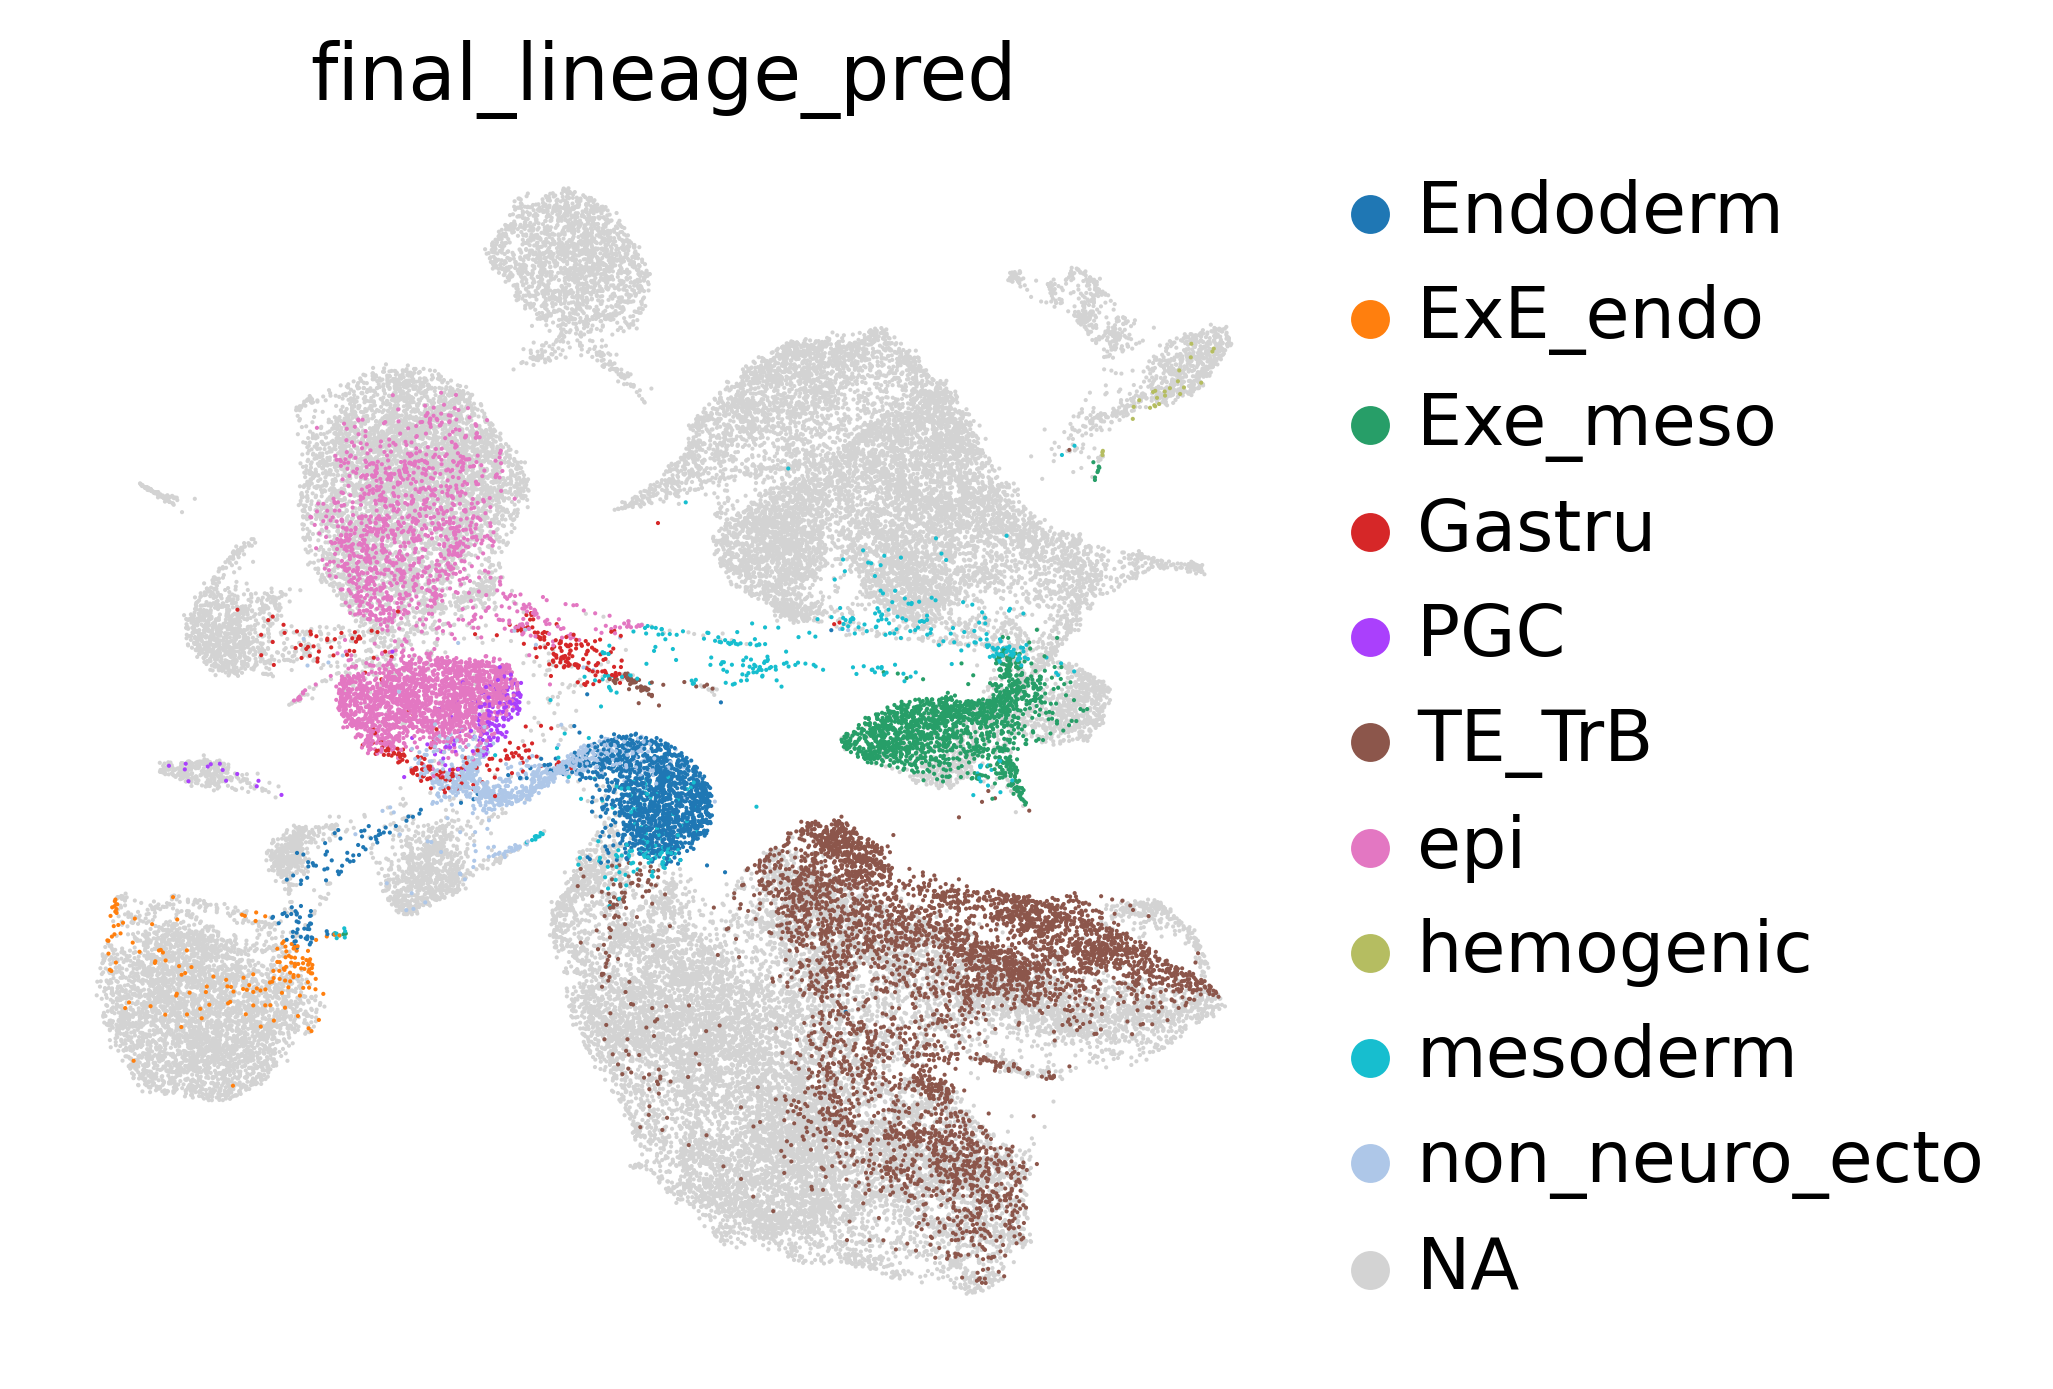

In [50]:
sc.pl.umap(
    adata_no_prototypes,
    color='final_lineage_pred',
    show=False,
    frameon=False,
)

<AxesSubplot: title={'center': 'orig.ident'}, xlabel='UMAP1', ylabel='UMAP2'>

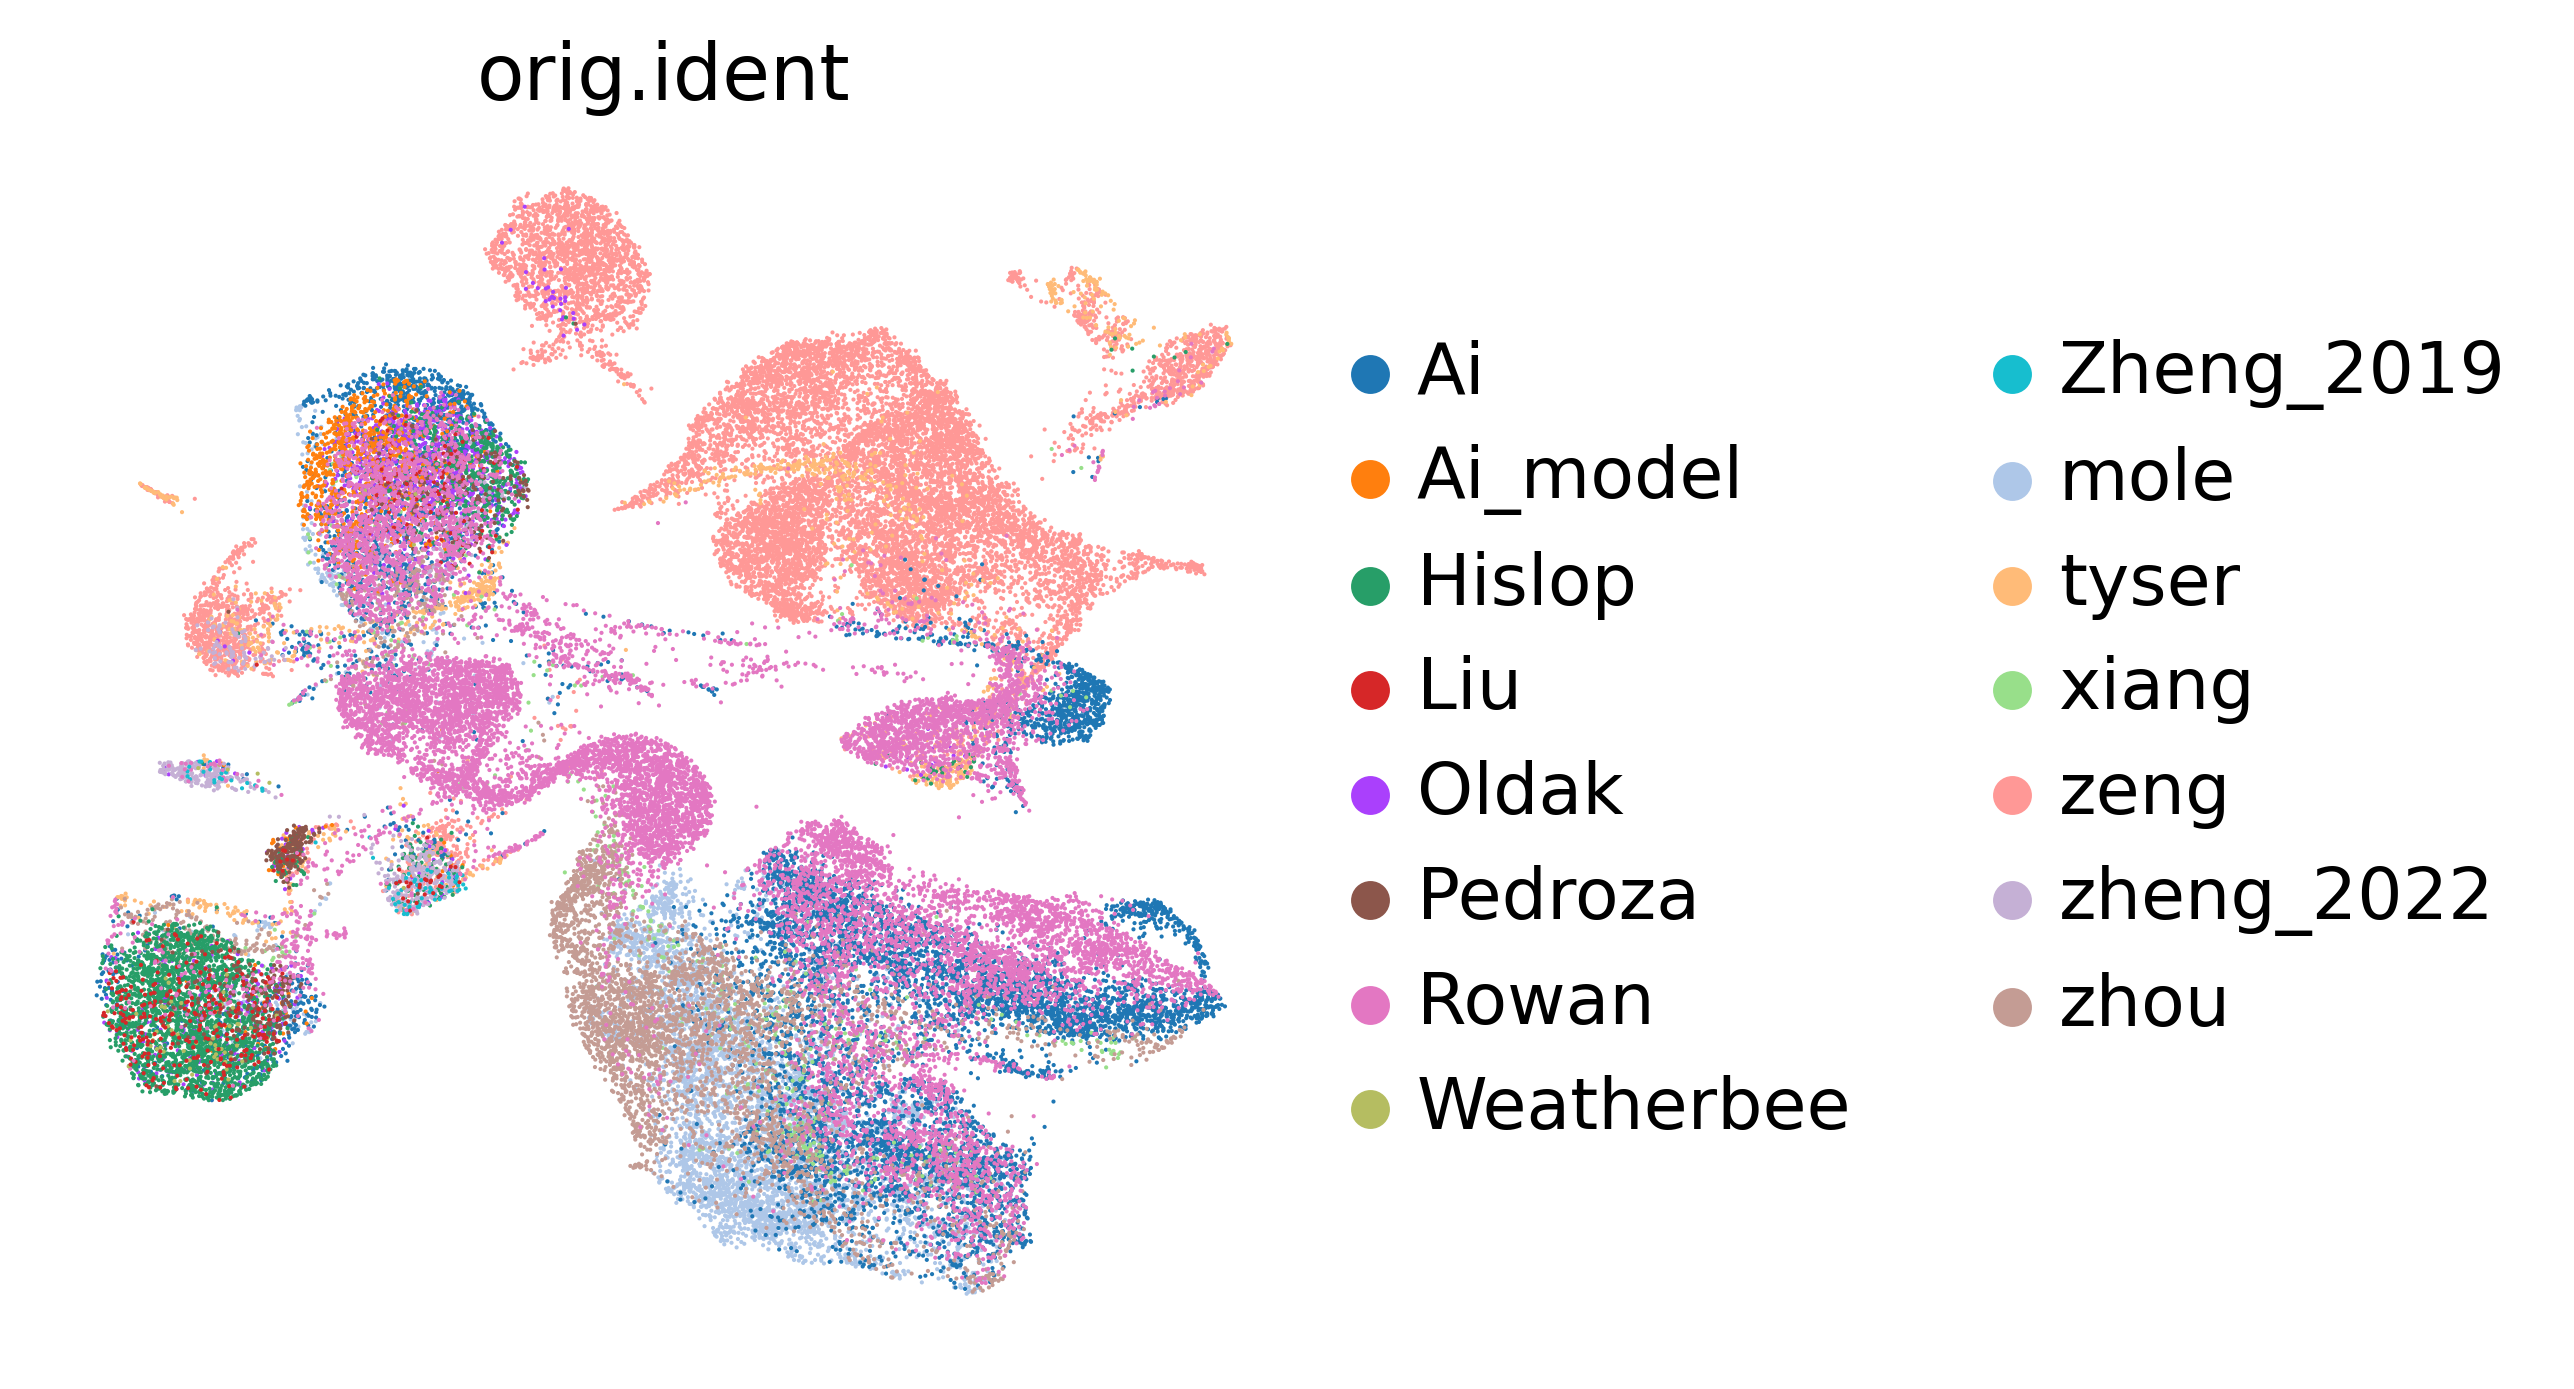

In [51]:
sc.pl.umap(
    adata_no_prototypes,
    color='orig.ident',
    show=False,
    frameon=False,
)

<AxesSubplot: title={'center': 'final_lineage_uncert'}, xlabel='UMAP1', ylabel='UMAP2'>

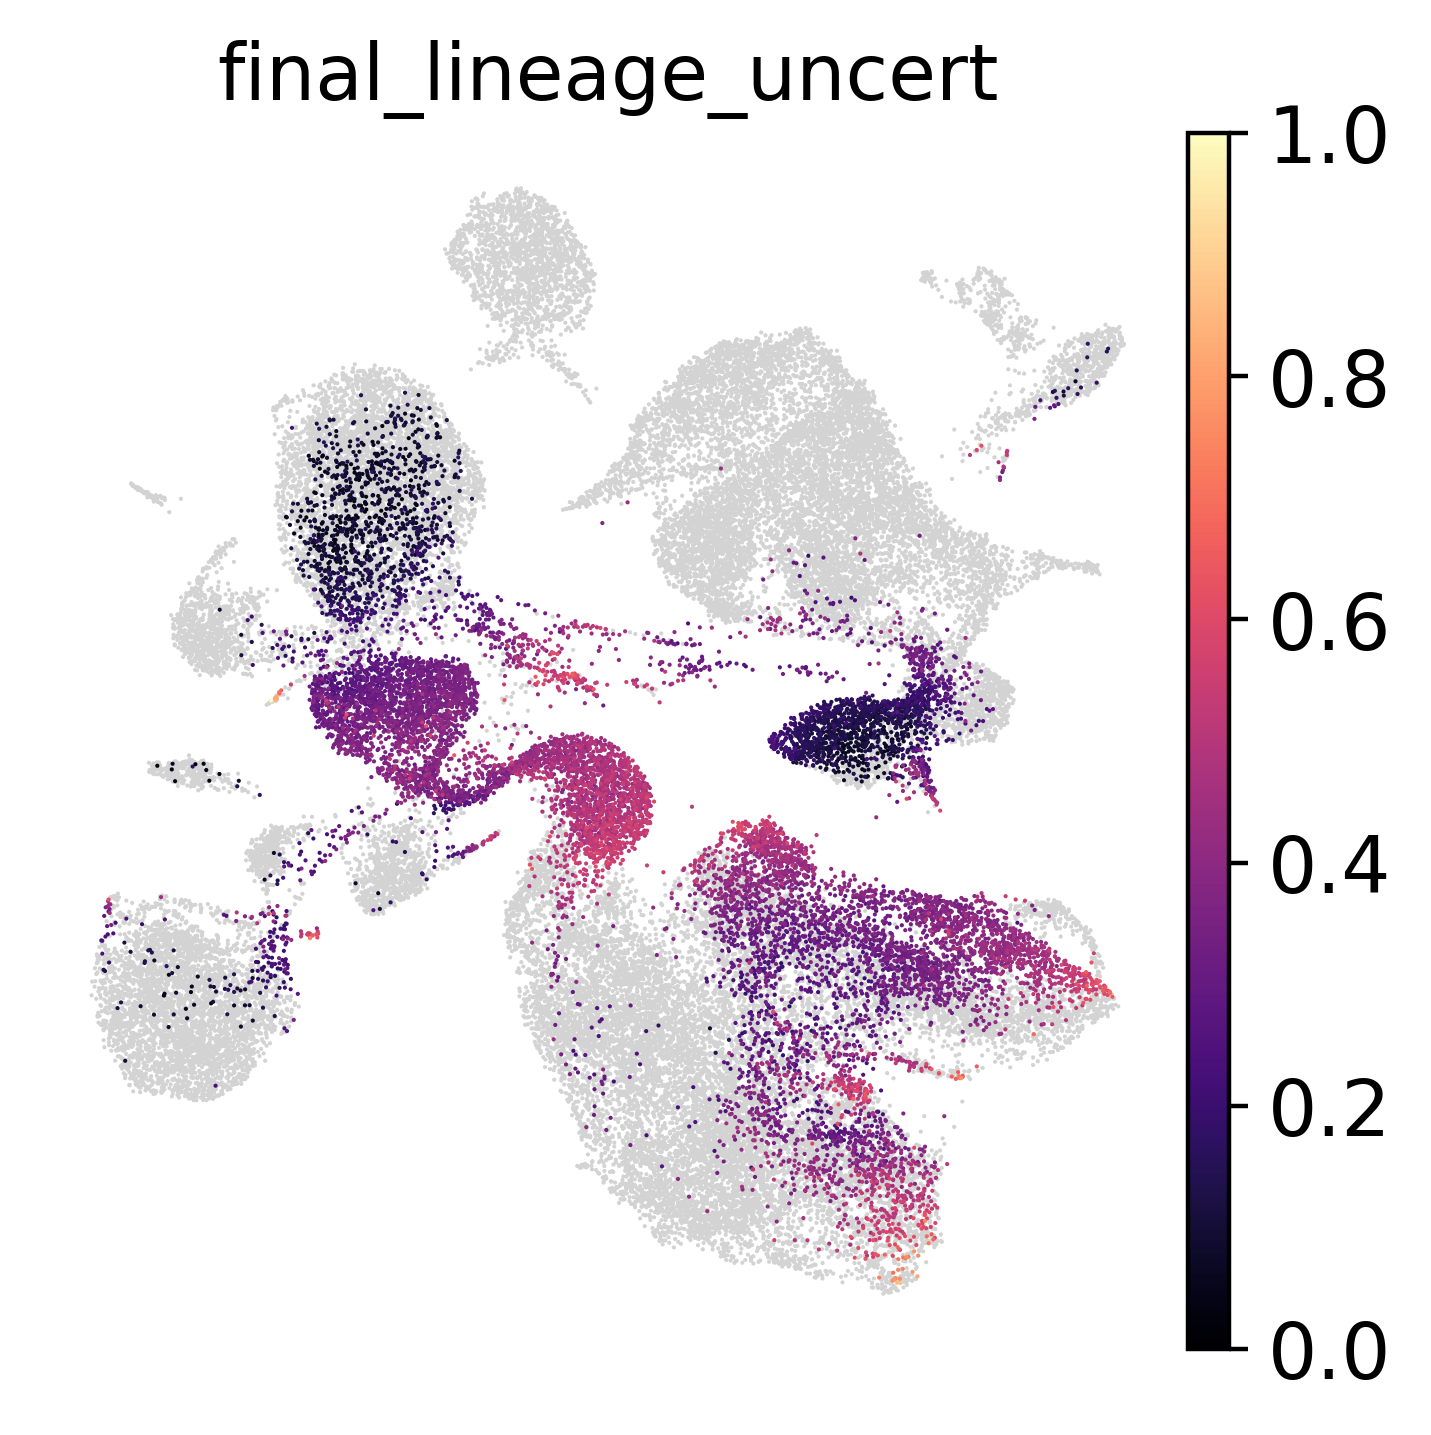

In [52]:
sc.pl.umap(
    adata_no_prototypes,
    color='final_lineage_uncert',
    show=False,
    frameon=False,
    cmap='magma',
    vmax=1
)

In [53]:
adata_latent

AnnData object with n_obs × n_vars = 12984 × 10
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'final_lineage', 'conditions_combined', 'final_lineage_pred', 'final_lineage_uncert', 'classifier_outcome'

In [54]:
sc.pp.neighbors(adata_latent)
sc.tl.leiden(adata_latent)
sc.tl.umap(adata_latent)

<AxesSubplot: title={'center': 'final_lineage_pred'}, xlabel='UMAP1', ylabel='UMAP2'>

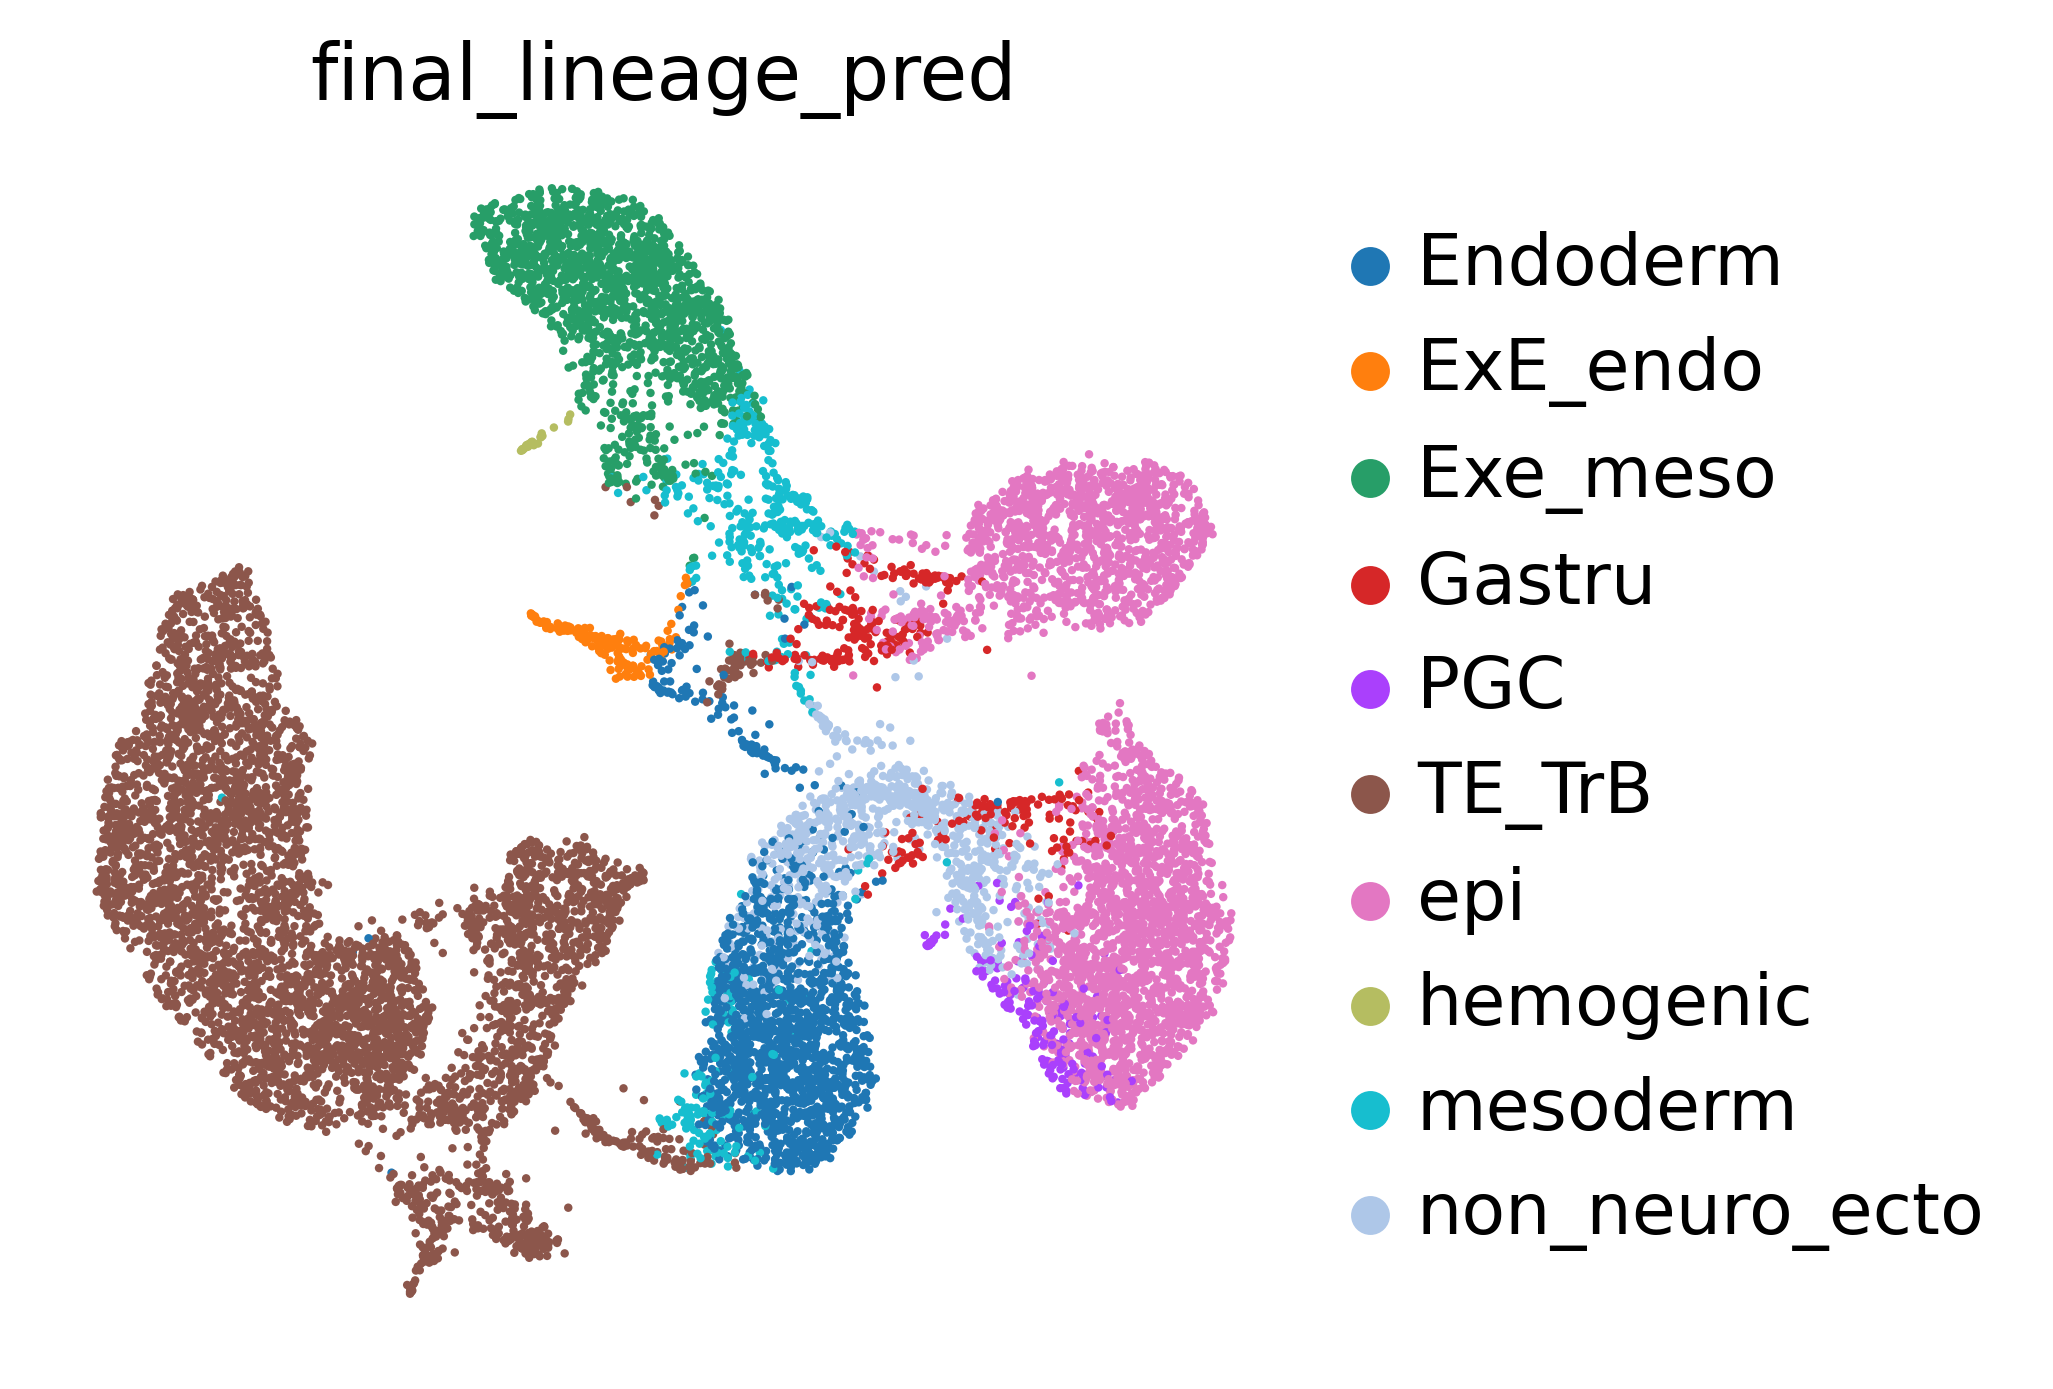

In [55]:
sc.pl.umap(
    adata_latent,
    color='final_lineage_pred',
    show=False,
    frameon=False,
)